# Práctica 2

Paso 0: Importar las librerías correspondientes

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import cartopy.feature as cfeature
import xarray as xr

In [2]:
import warnings
warnings.filterwarnings('ignore')

### Ejercicio 1
Abrir el archivo .nc y definir una variable con la región asignada. Determinar el tamaño de sus dimensiones Convertir las unidades a Celsius (K - 273.15) y actualizar los atributos de la variable.

In [3]:
# Abrir la data en el notebook
ds = xr.open_dataset(r'C:\Users\sebas\Downloads\era5_t2m_2026_daily.nc')

In [7]:
# Selección de la región "Llanos Orinoco"
lo = ds.sel(latitude=slice(9,3), longitude= slice(-72, -65))

# Determinar el tamaño total de sus dimensiones
lo.dims

FrozenMappingWarningOnValuesAccess({'valid_time': 251, 'latitude': 25, 'longitude': 29})

In [9]:
# Cambiar datos y unidades a Celsius
lo_t2m_c = lo['t2m']-273.15

lo_t2m_c.attrs.update({"units": "Celsius"})

In [10]:
lo_t2m_c

<xarray.DataArray 't2m' (valid_time: 251, latitude: 25, longitude: 29)> Size: 728kB
array([[[28.33667 , 28.209473, 28.059814, ..., 30.482422, 30.264893,
         29.644531],
        [28.277344, 27.52246 , 24.069336, ..., 30.285645, 30.036377,
         29.319336],
        [26.09253 , 23.5     , 19.057617, ..., 30.280273, 30.016602,
         29.233643],
        ...,
        [25.789307, 25.54004 , 25.436768, ..., 23.361816, 26.645508,
         24.560791],
        [25.461914, 25.342285, 25.130371, ..., 26.53247 , 27.429688,
         24.80249 ],
        [25.463379, 25.50879 , 25.40918 , ..., 26.6792  , 27.041016,
         25.868408]],

       [[27.972565, 27.80655 , 27.392487, ..., 30.277496, 30.017975,
         29.360992],
        [27.865631, 27.391998, 23.556305, ..., 30.127838, 29.809479,
         29.039215],
        [25.748932, 23.53238 , 18.694489, ..., 30.11905 , 29.869537,
         28.988434],
...
        [26.250702, 25.919647, 25.847626, ..., 23.338837, 26.419647,
         24.621796],
        [26.0466  , 25.737762, 25.647186, ..., 26.775116, 27.177704,
         24.530243],
        [26.11911 , 26.022675, 25.73117 , ..., 27.263641, 27.353973,
         26.119354]],

       [[30.27951 , 29.459686, 28.111053, ..., 30.290009, 30.579803,
         30.729706],
        [30.050507, 29.042694, 24.56247 , ..., 29.935272, 30.193817,
         30.170868],
        [27.308807, 25.336395, 20.260956, ..., 30.012909, 30.213104,
         29.879852],
        ...,
        [26.165985, 25.896698, 25.555145, ..., 23.906952, 27.09494 ,
         25.206757],
        [26.004608, 25.951385, 25.736053, ..., 27.311493, 28.044159,
         25.492645],
        [26.022186, 26.165497, 26.059296, ..., 27.671356, 28.116913,
         26.638885]]], shape=(251, 25, 29), dtype=float32)
Coordinates:
  * valid_time  (valid_time) datetime64[ns] 2kB 2026-01-01 ... 2026-09-08
  * latitude    (latitude) float64 200B 9.0 8.75 8.5 8.25 ... 3.75 3.5 3.25 3.0
  * longitude   (longitude) float64 232B -72.0 -71.75 -71.5 ... -65.25 -65.0
    number      int64 8B ...
Attributes: (12/32)
    GRIB_paramId:                             167
    GRIB_dataType:                            an
    GRIB_numberOfPoints:                      112672
    GRIB_typeOfLevel:                         surface
    GRIB_stepUnits:                           1
    GRIB_stepType:                            instant
    ...                                       ...
    GRIB_totalNumber:                         0
    GRIB_units:                               K
    long_name:                                2 metre temperature
    units:                                    Celsius
    standard_name:                            unknown
    GRIB_surface:                             0.0

### Ejercicio 2
a) Elegir una fecha arbitraria usando sel.() o isel() y graficar la variable (en Celsius) en un mapa, usando Cartopy.
b) Elige una paleta y niveles apropiados para tu rango de datos. Justifica la elección a modo de comentario en 1-2 líneas.
c) Agrega líneas de costa y grillas
d) Agrega los siguientes cfeatures:
 cfeature.STATES, edgecolor="gray" 
 cfeature.LAKES, color='skyblue'  
 cfeature.RIVERS, color='b' 
 cfeature.OCEAN, facecolor='lightcyan',zorder=10
e) Editar apropiadamente, el título y las etiquetas de los ejes X e Y.

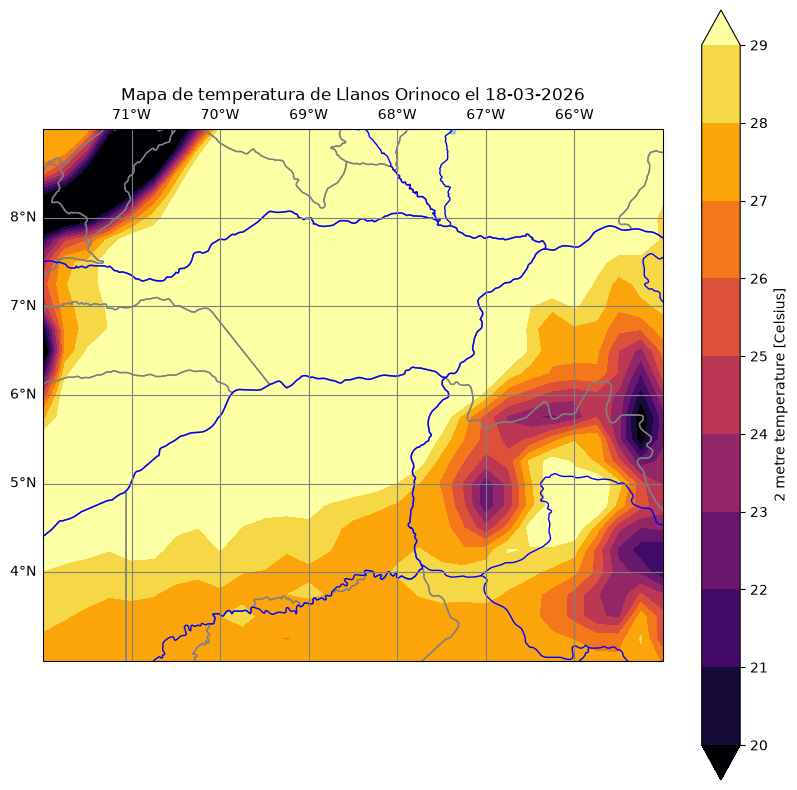

In [70]:
# Selección de fecha arbitraria
lo_fecha = lo_t2m_c.sel(valid_time='2026-03-18')

# Graficar selección usando cartopy
fig, ax = plt.subplots(figsize=(10,10), subplot_kw={'projection':ccrs.PlateCarree()})

lo_fecha.plot.contourf(ax=ax, transform=ccrs.PlateCarree(), 
                                               cmap='inferno', levels=np.arange(20,30,1))
# El color fue seleccionado pues corresponde a una paleta secuencial que presenta el gradiente entre dos tonalidades.
# Al trabajar con temperatura, el tono más oscuro corresponde a una temperatura más baja y viceversa. Es intuitivo y
# de fácil interpretación. El rango de datos fue seleccionado para identificar los puntos de variación de temperatura
# en el terreno.

# Agregar líneas de costa y grillas
ax.coastlines()
gl = ax.gridlines(draw_labels=True, color='gray')
gl.right_labels=False
gl.bottom_labels=False

# Agregar features
ax.add_feature(cfeature.STATES, edgecolor='gray')
ax.add_feature(cfeature.LAKES, color='skyblue')
ax.add_feature(cfeature.RIVERS, color='blue')
ax.add_feature(cfeature.OCEAN, facecolor='lightcyan', zorder=10)

# Editar etiquetas
ax.set_title('Mapa de temperatura de Llanos Orinoco el 18-03-2026')
ax.set_ylabel('Latitud')
ax.set_xlabel('Longitud')

plt.show()

### Ejercicio 3
a) Para la misma fecha analizada en la pregunta anterior, selecciona dos latitudes con diferentes elementos geográficos y extrae el transecto utilizanto .sel(). b) Grafica la temperatura a lo largo de esos transectos. c) Cada transecto debe tener un color diferente y adecuada leyenda

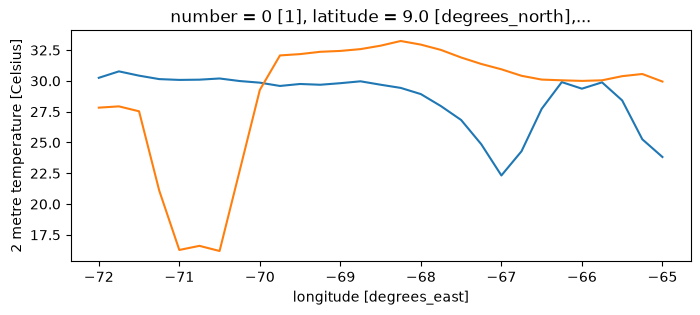

In [69]:
# Selección de dos latitudes
# Latitud 9: Cruza un lago entre 68W y 67W
# Latitud 5: Cruza ríos en 4 puntos diferentes

# Graficar las latitudes
fig = plt.subplots(figsize=(8,3))

lo_fecha.sel(latitude=5).plot(label='5 °N')
lo_fecha.sel(latitude=9).plot(label='9 °N')

ax.set_title('Variación de temperatura a lo largo de dos latitudes')
ax.set_xlabel('Longitud (°W)')
ax.set_ylabel('Temperatura (°C)')

ax.legend()
plt.show()

### Ejercicio 4
qrstu

### Ejercicio 5
vwxyz